# Time Series Analysis

## Libraries used

In [4]:
# imports
# !pip install wfdb
# !pip install torch torchvision torchaudio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
from collections import Counter

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Task 1: Data Loading & Exploration (Víctor)

In [5]:
# display options
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', context='notebook')

# the 14 records selected by the assignment
RECORDS = ['100', '101', '105', '106', '108', '109', '111',
           '112', '115', '117', '119', '201', '213', '219']
# 3-class scheme
LABEL_MAP = {
    # N — Normal / bundle branch
    'N': 'N', '.': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    # S — Supraventricular ectopic
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    # V — Ventricular ectopic
    'V': 'V', 'E': 'V',
}

# colours for each class
CLASS_COLORS = {'N': '#2ca02c', 'S': '#1f77b4', 'V': '#d62728'}

In [6]:
# load the 14 records
records_data = {}
for rid in RECORDS:
    rec = wfdb.rdrecord(rid, pn_dir='mitdb')
    ann = wfdb.rdann(rid, 'atr', pn_dir='mitdb')
    records_data[rid] = {
        'signal':  rec.p_signal[:, 0],
        'fs':      rec.fs,
        'samples': np.asarray(ann.sample),
        'symbols': np.asarray(ann.symbol),
    }

FS = records_data['100']['fs']
n_total_annotations = sum(d['samples'].size for d in records_data.values())

print(f'Records loaded         : {len(records_data)}')
print(f'Sampling rate          : {FS} Hz')
print(f'Signal shape (record 100): {records_data["100"]["signal"].shape}')
print(f'Total raw annotations  : {n_total_annotations:,}')

Records loaded         : 14
Sampling rate          : 360 Hz
Signal shape (record 100): (650000,)
Total raw annotations  : 31,219


The 14 records were loaded without any problem at 360Hz, with 30 minutes of every signal (650000 samples = 30min x 60s x 360Hz). We have 31.219 raw annotations before applying AAMI.

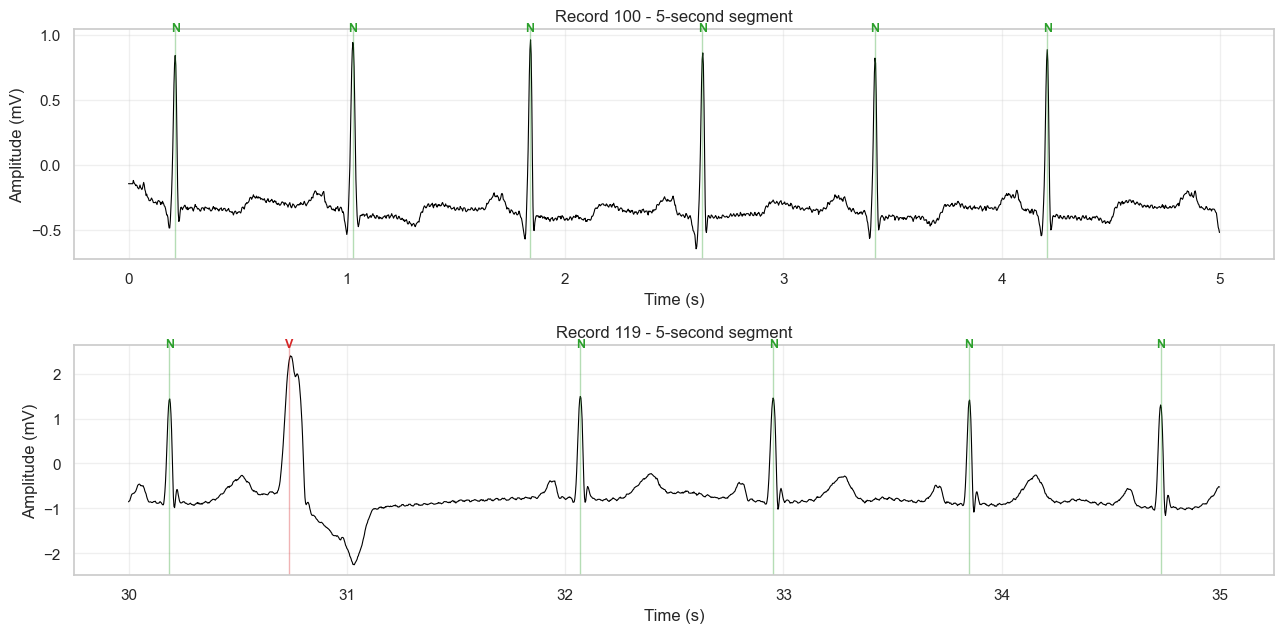

In [44]:
# ECG signals plots
def plot_ecg_segment(record_id, start_seconds, duration_seconds, ax):
    d = records_data[record_id]
    fs = d['fs']
    start = int(start_seconds * fs)
    end   = int((start_seconds + duration_seconds) * fs)
    signal = d['signal'][start:end]
    t = np.arange(start, end) / fs

    ax.plot(t, signal, color='black', lw=0.8)

    in_seg = (d['samples'] >= start) & (d['samples'] < end)
    for s, sym in zip(d['samples'][in_seg], d['symbols'][in_seg]):
        aami = LABEL_MAP.get(sym, '?')
        color = CLASS_COLORS.get(aami, 'gray')
        ax.axvline(s / fs, color=color, alpha=0.35, lw=1)
        ax.text(s / fs, signal.max() * 1.05, sym, color=color,
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude (mV)')
    ax.set_title(f'Record {record_id} - {duration_seconds}-second segment')
    ax.grid(alpha=0.3)

fig, axes = plt.subplots(2, 1, figsize=(13, 6.5))
plot_ecg_segment('100', start_seconds=0,  duration_seconds=5, ax=axes[0])
plot_ecg_segment('119', start_seconds=30, duration_seconds=5, ax=axes[1])
plt.tight_layout()
plt.show()

Record 100 shows regular sinus rhythm (six N beats evenly spaced at ~0.8 s with consistent narrow-QRS morphology).

Record 119 highlights the contrast the classifier must learn: a single V beat (red) appears between normal beats, with markedly wider QRS, nearly double the amplitude and a clearly distinct shape.

The grey + markers correspond to rhythm-change annotations, which are not part of the AAMI scheme and will be discarded in the next step.

Total annotations : 30,162
Kept (N/S/V)      : 30,162
Discarded         : 0

Discarded symbols (top 10):
Series([], )
      count  proportion
aami                   
N     28412      0.9420
S       206      0.0068
V      1544      0.0512


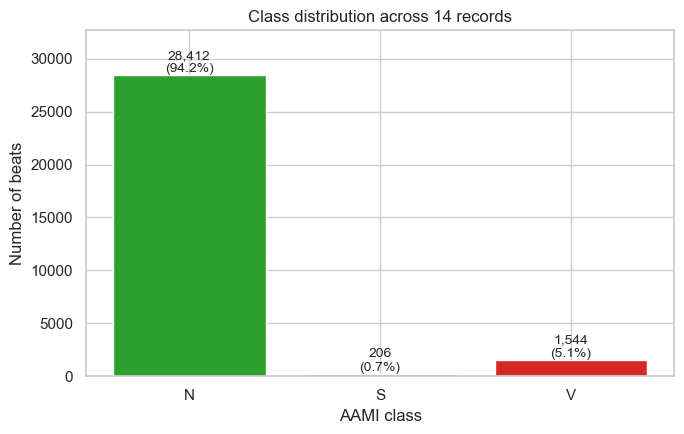

In [47]:
# AAMI label mapping and class distribution
rows = []
for rid, d in records_data.items():
    for s, sym in zip(d['samples'], d['symbols']):
        rows.append({'record_id': rid, 'sample': s, 'symbol': sym,
                     'aami': LABEL_MAP.get(sym, None)})

annotations_df = pd.DataFrame(rows)
beats_df = annotations_df.dropna(subset=['aami']).reset_index(drop=True)

n_kept     = len(beats_df)
n_discard  = len(annotations_df) - n_kept

print(f'Total annotations : {len(annotations_df):,}')
print(f'Kept (N/S/V)      : {n_kept:,}')
print(f'Discarded         : {n_discard:,}')
print('\nDiscarded symbols (top 10):')
print(annotations_df[annotations_df['aami'].isna()]['symbol']
      .value_counts().head(10).to_string())

class_counts = beats_df['aami'].value_counts().reindex(['N', 'S', 'V'])
class_props  = beats_df['aami'].value_counts(normalize=True).reindex(['N', 'S', 'V'])

balance = pd.DataFrame({'count': class_counts, 'proportion': class_props.round(4)})
print(balance)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(class_counts.index, class_counts.values,
              color=[CLASS_COLORS[c] for c in class_counts.index])
for b, v in zip(bars, class_counts.values):
    ax.text(b.get_x() + b.get_width()/2, v,
            f'{v:,}\n({v/class_counts.sum()*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Number of beats')
ax.set_xlabel('AAMI class')
ax.set_title('Class distribution across 14 records')
ax.set_ylim(0, class_counts.max() * 1.15)
plt.tight_layout()
plt.show()

After applying the AAMI mapping, 30,162 beats are retained (96.6% of the 31,219 raw annotations) and 1,057 are discarded, mostly fusion beats (F, n=369), rhythm-change markers (52) and noise annotations (196).
The class distribution is severely imbalanced: 94.2% N, 5.1% V and only 0.7% (just 206 beats across all 14 records). This confirms that macro F1 is the only sensible headline metric.

In [46]:
#heatmap(need features) will be executed at the end of task 2

def plot_feature_correlation(features_df):
    available = [c for c in FEATURE_NAMES if c in features_df.columns]
    corr = features_df[available].corr()

    fig, ax = plt.subplots(figsize=(8, 6.5))
    sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1,
                annot=True, fmt='.2f', square=True, linewidths=0.4,
                cbar_kws={'shrink': 0.75}, ax=ax)
    ax.set_title('Pearson correlation - 8 engineered features')
    plt.tight_layout()
    plt.show()

    # Top correlated pairs
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    pairs = (corr.where(mask).stack()
                 .rename('corr').reset_index()
                 .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2'}))
    pairs['abs_corr'] = pairs['corr'].abs()
    top = pairs.sort_values('abs_corr', ascending=False).head(5).reset_index(drop=True)
    print('Top 5 correlated feature pairs:')
    print(top.round(3).to_string(index=False))

## Task 2: Preprocessing & Feature Analysis (Ana)

### 2.1 AAMI Label Mapping and Beat Filtering

The original heartbeat annotations are mapped into the selected AAMI classes. Beats that do not belong to the target classes are removed so that the dataset focuses only on the categories used for classification.

In [10]:
# AAMI label mapping and class distribution

discarded_symbols = []
discarded_indices = []

for rid, d in records_data.items():

    # map symbols to AAMI classes
    aami = [LABEL_MAP.get(sym, None) for sym in d['symbols']]

    # valid beats mask
    valid_mask = np.array([lbl is not None for lbl in aami])

    # save discarded info BEFORE filtering
    discarded_symbols.extend(d['symbols'][~valid_mask])

    discarded_indices.extend(
        [(rid, idx) for idx in np.where(~valid_mask)[0]]
    )

    # keep only valid beats
    records_data[rid]['samples'] = d['samples'][valid_mask]
    records_data[rid]['symbols'] = d['symbols'][valid_mask]
    records_data[rid]['aami'] = np.array(aami)[valid_mask]

print(f'Total annotations : {len(discarded_indices) + sum(len(d["samples"]) for d in records_data.values()):,}')
print(f'Kept (N/S/V)      : {sum(len(d["samples"]) for d in records_data.values()):,}')
print(f'Discarded         : {len(discarded_indices):,}')


Total annotations : 31,219
Kept (N/S/V)      : 30,162
Discarded         : 1,057


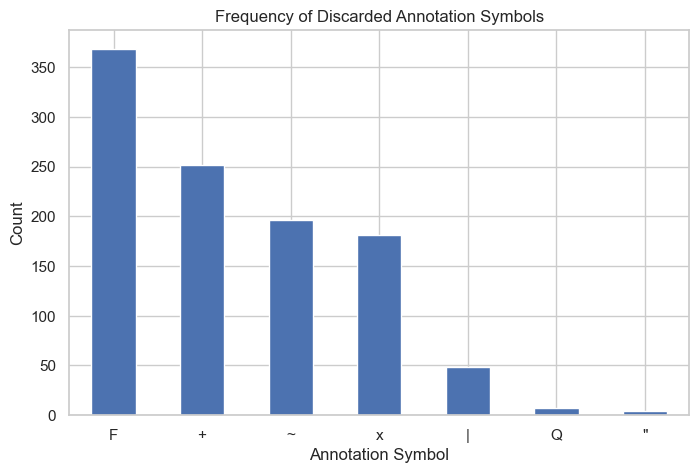

In [11]:
# frequency of discarded symbols
discarded_counts = pd.Series(discarded_symbols).value_counts()

# bar chart
plt.figure(figsize=(8, 5))
discarded_counts.plot(kind='bar')

plt.title('Frequency of Discarded Annotation Symbols')
plt.xlabel('Annotation Symbol')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

### 2.2 Feature Extraction: 8 Features per Beat

For each heartbeat, eight descriptive features are extracted from the ECG signal.

In [12]:
FEATURE_NAMES = ['RR_current', 'RR_prev', 'RR_ratio', 'RR_local_mean', 'R_amplitude', 'QRS_duration', 'QRS_energy', 'ST_mean']

In [13]:
min_len = min(len(d['samples']) for d in records_data.values())
print(min_len)

1535


In [14]:
# Function to compute the 'QRS_duration' using a threshold-based method around the R-peak
def find_qrs_duration(signal, r_idx, R_amplitude):

    # QRS duration estimates the width of the ventricular depolarization complex
    # using a threshold-based method around the R-peak.

    threshold = 0.5 * R_amplitude  # 50% of peak amplitude (adaptive threshold)

    # LEFT CROSSING: search backwards from R-peak until signal drops below threshold
    left_cross = None
    for i in range(r_idx, -1, -1):
        if signal[i] < threshold:
            left_cross = i
            break

    # RIGHT CROSSING: search forward from R-peak until signal drops below threshold
    right_cross = None
    for i in range(r_idx, len(signal)):
        if signal[i] < threshold:
            right_cross = i
            break

    # If boundaries are not found, return NaN (robust handling of edge cases/noise)
    if left_cross is None or right_cross is None:
        return np.nan

    # QRS duration in samples (can be converted to ms if needed)
    return right_cross - left_cross

In [15]:
import warnings
warnings.simplefilter("error")
record_features = []

# Iterate over each ECG record independently to preserve patient-level structure
for rid, d in records_data.items():

    signal = d['signal']
    fs = d['fs']
    samples = d['samples']
    labels = d['aami']

    # Each sample corresponds to an R-peak (one heartbeat)
    for i in range(len(samples)):

        r_idx = samples[i]

        # ---------------- RR INTERVAL FEATURES ----------------
        # RR features capture temporal variability between consecutive heartbeats

        if i >= 4:

            # Current and previous RR intervals (beat-to-beat timing)
            rr_current = (samples[i] - samples[i-1]) / fs * 1000
            rr_prev = (samples[i-1] - samples[i-2]) / fs * 1000

            # Local rhythm baseline computed over last 5 beats (i-4 to i)
            rr_local_mean = np.mean([
                (samples[i-3] - samples[i-4]),
                (samples[i-2] - samples[i-3]),
                (samples[i-1] - samples[i-2]),
                (samples[i]   - samples[i-1])
            ]) / fs * 1000

            # Relative deviation from local rhythm
            rr_ratio = rr_current / rr_local_mean if rr_local_mean != 0 else 0

        else:
            # Edge case: first beats (insufficient history)
            # Approximate using first 5 RR intervals of the record
            rr_local_mean = np.mean([
                (samples[j] - samples[j-1]) / fs * 1000
                for j in range(1, 5)
            ])

            rr_current = rr_local_mean
            rr_prev = rr_local_mean
            rr_ratio = 1.0

        # ---------------- MORPHOLOGICAL FEATURES ----------------
        # Extracted around the R-peak to capture beat morphology

        # Local R amplitude (QRS peak intensity)
        r_amplitude = np.mean(signal[r_idx-5:r_idx+6])

        # QRS duration: width of ventricular depolarization
        qrs_duration = find_qrs_duration(signal, r_idx, r_amplitude)

        # QRS energy: total electrical activity in QRS complex
        qrs_energy = np.sum(signal[r_idx-20:r_idx+21] ** 2)

        # ST segment: early repolarization phase after QRS complex
        if r_idx + 40 < len(signal):
            st_mean = np.mean(signal[r_idx+40 : min(r_idx+120, len(signal))])
        else:
            st_mean = np.nan

        # ---------------- STORE FEATURE VECTOR ----------------
        record_features.append({
            'record_id': rid,        # used for traceability (not model input)
            'sample': r_idx,         # R-peak position in signal
            'RR_current': rr_current,
            'RR_prev': rr_prev,
            'RR_ratio': rr_ratio,
            'RR_local_mean': rr_local_mean,
            'R_amplitude': r_amplitude,
            'QRS_duration': qrs_duration,
            'QRS_energy': qrs_energy,
            'ST_mean': st_mean,
            'label': labels[i]
        })

# Final feature matrix (one row per heartbeat)
features_df = pd.DataFrame(record_features)

In [16]:
for col in FEATURE_NAMES:
    n_missing = features_df[col].isna().sum()
    print(f'Feature "{col}" has {n_missing} missing values.')

Feature "RR_current" has 0 missing values.
Feature "RR_prev" has 0 missing values.
Feature "RR_ratio" has 0 missing values.
Feature "RR_local_mean" has 0 missing values.
Feature "R_amplitude" has 0 missing values.
Feature "QRS_duration" has 0 missing values.
Feature "QRS_energy" has 0 missing values.
Feature "ST_mean" has 2 missing values.


In [17]:
features_df = features_df.dropna()

#### First-beat edge case handling

The first beats in each ECG record do not have sufficient previous R-peak information to compute RR-based features (RR_current, RR_prev, and RR_local_mean).

To handle this boundary condition, these features were approximated using the mean RR interval of the first five available beats in the record.

This approach provides a stable baseline estimate of the heart rhythm and avoids introducing missing values or artificial bias at the beginning of each sequence.

Additionally, for the ST_mean feature, the extraction window was right-truncated at the signal boundary (min(r_idx + 120, len(signal))) to avoid out-of-bounds indexing. If the window exceeded the signal length, the mean was computed using the available samples only.

Two beats produced missing values for ST_mean because they were located near the end of the ECG signal and did not contain enough subsequent samples (+40) to define the ST-segment window. Since these represented a negligible proportion of the dataset, the corresponding beats were removed prior to training.

In [18]:
features_df.head()

,record_id,sample,RR_current,RR_prev,RR_ratio,RR_local_mean,R_amplitude,QRS_duration,QRS_energy,ST_mean,label
0,100,77,801.388889,801.388889,1.000000,801.388889,0.326364,8,6.79495,-0.343125,N
1,100,370,801.388889,801.388889,1.000000,801.388889,0.495455,8,8.95210,-0.410688,N
2,100,662,801.388889,801.388889,1.000000,801.388889,0.347727,7,9.14830,-0.394750,N
3,100,946,801.388889,801.388889,1.000000,801.388889,0.307727,7,9.52190,-0.365687,N
4,100,1231,791.666667,788.888889,0.987868,801.388889,0.250000,8,8.07610,-0.404250,N


In [19]:
features_df.shape

(30160, 11)

### 2.3 Correlation Analysis (task 1)

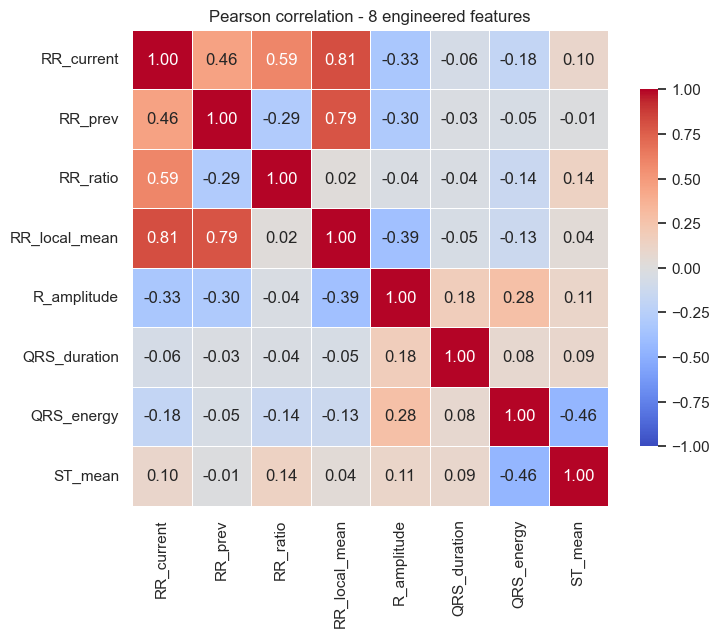

Top 5 correlated feature pairs:
 feature_1     feature_2   corr  abs_corr
RR_current RR_local_mean  0.813     0.813
   RR_prev RR_local_mean  0.791     0.791
RR_current      RR_ratio  0.588     0.588
RR_current       RR_prev  0.460     0.460
QRS_energy       ST_mean -0.459     0.459


In [48]:
#heatmap (task 1)
plot_feature_correlation(features_df)

### 2.4 Sliding Window Construction for RNN and LSTM

Sequential windows of consecutive heartbeats are created for the recurrent models. Each window provides temporal context, allowing the RNN and LSTM to learn patterns across multiple beats instead of treating each beat independently. For each beat at position i ≥ 10, a sample is created consisting of the feature vectors for beats i−9 through i (shape: 10 × 8) with label equal to the class of beat i.

In [21]:
# Sliding Window Construction record-by-record
WINDOW_SIZE = 10
FEATURE_COLS = ['RR_current', 'RR_prev', 'RR_ratio', 'RR_local_mean',
                'R_amplitude', 'QRS_duration', 'QRS_energy', 'ST_mean']

# Step 1: build sliding windows record by record, in temporal order
# This ensures each window contains 10 truly consecutive beats from the same record
X_windows = []
y_windows = []

for rid, group in features_df.groupby('record_id'):
    group = group.sort_values('sample').reset_index(drop=True)
    X_record = group[FEATURE_COLS].values
    y_record = group['label'].values

    for i in range(WINDOW_SIZE - 1, len(group)):
        X_windows.append(X_record[i - WINDOW_SIZE + 1 : i + 1])
        y_windows.append(y_record[i])

X_windows = np.array(X_windows)   # shape: (n_sequences, 10, 8)
y_windows = np.array(y_windows)

print(f'Sequences shape: {X_windows.shape}')
print(f'Labels shape:    {y_windows.shape}')


Sequences shape: (30034, 10, 8)
Labels shape:    (30034,)


### 2.5 Train-Test Split

The feature dataset is divided into training and test sets using stratified sampling. This preserves the class distribution in both sets, which is especially important because the heartbeat classes are imbalanced.

In [22]:
# Step 2: stratified train/test split on the already-formed sequences
from sklearn.model_selection import train_test_split

X_train_windows, X_test_windows, y_train_windows, y_test_windows = train_test_split(
    X_windows, y_windows, test_size=0.2, random_state=RANDOM_STATE, stratify=y_windows
)

print(f'Train sequences: {X_train_windows.shape}')
print(f'Test sequences:  {X_test_windows.shape}')

# Class distribution summary
def class_summary(y):
    y = pd.Series(y)
    df = y.value_counts().to_frame('beat count')
    df['percentage'] = y.value_counts(normalize=True) * 100
    return df

print("Train:")
print(class_summary(y_train_windows))

print("\nTest:")
print(class_summary(y_test_windows))

Train sequences: (24027, 10, 8)
Test sequences:  (6007, 10, 8)
Train:
   beat count  percentage
N       22629   94.181546
V        1234    5.135889
S         164    0.682565

Test:
   beat count  percentage
N        5658   94.190112
V         308    5.127351
S          41    0.682537


Stratified split ensures that the strong class imbalance of the dataset is preserved in both training and test sets.

### 2.6 Feature Scaling

The features (all are numerical) are standardized using statistics learned from the training set only. Scaling ensures that all features contribute comparably and prevents larger-valued variables from dominating the models.

In [23]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
# (n_sequences * 10, 8)
X_train_2d = X_train_windows.reshape(-1, X_train_windows.shape[-1])
X_test_2d = X_test_windows.reshape(-1, X_test_windows.shape[-1])

# Scale the 2D arrays
X_train_scaled = scaler.fit_transform(X_train_2d)
X_test_scaled = scaler.transform(X_test_2d)

# Convert back to df
X_train_scaled = X_train_scaled.reshape(X_train_windows.shape)
X_test_scaled = X_test_scaled.reshape(X_test_windows.shape)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(24027, 10, 8)
(6007, 10, 8)


## Task 3: RNN Sequence Classification (Kamela)

In this task, a vanilla Recurrent Neural Network (RNN) is trained to classify cardiac beats using the sliding-window dataset constructed in Task 2.

Each input sample contains 10 consecutive beats, where each beat is represented by 8 engineered features. The label corresponds to the class of the final beat in the sequence. This gives each sample the shape:

`(10, 8)`

The goal is to evaluate whether short-term temporal dependencies between neighbouring beats improve arrhythmia classification compared with treating beats independently.

The assignment requires a vanilla `torch.nn.RNN`, trained for at least 20 epochs, followed by training curves, a classification report, a confusion matrix, and interpretation of the results.

In [24]:
# ============================================================
# Task 3 — RNN Sequence Classification
# ============================================================

import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cpu


### 3.1 Sliding Window Dataset

The RNN receives a sequence of 10 consecutive beats. The target label is taken from the final beat in the window.

This structure allows the model to use recent rhythm history, such as previous RR intervals and local beat-to-beat variation, when classifying the current beat.

In [25]:
# Sequences already built in Task 2 - verify shapes before training
print("Training sequence shape:", X_train_scaled.shape)
print("Test sequence shape:    ", X_test_scaled.shape)

Training sequence shape: (24027, 10, 8)
Test sequence shape:     (6007, 10, 8)


The sliding-window transformation produced 24,027 training sequences and 6,007 test sequences.

Each input sequence has shape `(10, 8)`, meaning that the model receives 10 consecutive heartbeats with 8 engineered features per beat. The target label corresponds to the final beat in each window.

The windows overlap substantially because consecutive sequences share neighbouring beats. This increases the number of training samples while preserving short-term temporal continuity between heartbeats.

The sliding-window sequences were constructed record by record from the unscaled feature matrix, then split into training and test sets, and subsequently standardised using statistics derived from the training set only. 

In [26]:
# ============================================================
# Create Validation Split
# ============================================================

X_train_seq, X_val_seq, y_train_seq, y_val_seq = train_test_split(
    X_train_scaled,
    y_train_windows,
    test_size=0.20,
    stratify=y_train_windows,
    random_state=RANDOM_STATE
)
# to mantain the same names
X_test_seq = X_test_scaled
y_test_seq = y_test_windows

print("Training shape:", X_train_seq.shape)
print("Validation shape:", X_val_seq.shape)
print("Test shape:", X_test_seq.shape)

Training shape: (19221, 10, 8)
Validation shape: (4806, 10, 8)
Test shape: (6007, 10, 8)


After creating the 10-beat sliding windows, the training sequences were further divided into training and validation subsets.

The final sequence dataset sizes were:

- Training: 19,221 sequences
- Validation: 4,806 sequences
- Test: 6,007 sequences

Each sequence has shape `(10, 8)`, matching the required RNN input format. The test set was kept separate throughout the process and was used only for final evaluation.

In [27]:
# ============================================================
# Encode Class Labels
# ============================================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_seq = label_encoder.fit_transform(y_train_seq)
y_val_seq = label_encoder.transform(y_val_seq)
y_test_seq = label_encoder.transform(y_test_seq)

print("Encoded classes:", label_encoder.classes_)


# ============================================================
# PyTorch Dataset and DataLoader
# ============================================================

class ECGSequenceDataset(Dataset):
    """
    PyTorch Dataset for ECG sliding-window sequences.
    """

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]


BATCH_SIZE = 64

train_dataset = ECGSequenceDataset(X_train_seq, y_train_seq)
val_dataset = ECGSequenceDataset(X_val_seq, y_val_seq)
test_dataset = ECGSequenceDataset(X_test_seq, y_test_seq)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

batch_X, batch_y = next(iter(train_loader))

print("One batch X shape:", batch_X.shape)
print("One batch y shape:", batch_y.shape)

Encoded classes: ['N' 'S' 'V']
One batch X shape: torch.Size([64, 10, 8])
One batch y shape: torch.Size([64])


The class labels were encoded into integer format because PyTorch classification models require numerical target labels.

The encoded mapping was:

- N → 0
- S → 1
- V → 2

The training DataLoader uses shuffling so that batches are presented in a mixed order during optimisation. The validation and test DataLoaders are not shuffled because they are used only for evaluation.

A sample training batch has shape `torch.Size([64, 10, 8])`, confirming that each batch contains 64 sequences, each with 10 beats and 8 features per beat. The label batch has shape `torch.Size([64])`, which is correct for multi-class classification using cross-entropy loss.

### 3.2 Vanilla RNN Model

A vanilla RNN classifier was implemented using `torch.nn.RNN`.

The model consists of:

- input size: 8 features per beat
- sequence length: 10 beats
- one recurrent hidden layer
- hidden size: 64
- final fully connected output layer
- 3 output classes: N, S, and V

The RNN processes the 10-beat sequence in order and the output from the final timestep is passed into the linear layer. The final timestep is used because the target label corresponds to the final beat in each sliding window.

In [28]:
# ============================================================
# Vanilla RNN Model
# ============================================================

class RNNClassifier(nn.Module):
    """
    Vanilla RNN classifier for ECG sequence classification.
    """

    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        batch_size = x.size(0)

        h0 = torch.zeros(
            self.num_layers,
            batch_size,
            self.hidden_size,
            device=x.device
        )

        output, hidden = self.rnn(x, h0)

        final_timestep_output = output[:, -1, :]

        logits = self.classifier(final_timestep_output)

        return logits


INPUT_SIZE = 8
HIDDEN_SIZE = 64
NUM_LAYERS = 1
NUM_CLASSES = 3
LEARNING_RATE = 0.001
NUM_EPOCHS = 20

model = RNNClassifier(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print(model)

RNNClassifier(
  (rnn): RNN(8, 64, batch_first=True)
  (classifier): Linear(in_features=64, out_features=3, bias=True)
)


The vanilla RNN architecture was successfully initialised.

The model contains one recurrent layer with 64 hidden units and a final fully connected layer with 3 output neurons corresponding to the N, S, and V classes.

The RNN processes each 10-beat sequence in temporal order. The output from the final timestep is passed to the classifier because the target label corresponds to the final beat in the sliding window.

### 3.3 Training Procedure

The model was trained for 20 epochs using cross-entropy loss and the Adam optimiser.

Training and validation loss and accuracy were recorded at each epoch to monitor convergence and possible overfitting.

In [29]:
# ============================================================
# Training and Evaluation Helper Functions
# ============================================================

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

        predictions = torch.argmax(logits, dim=1)
        correct_predictions += (predictions == y_batch).sum().item()
        total_samples += y_batch.size(0)

    epoch_loss = total_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    return epoch_loss, epoch_accuracy


def evaluate(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)

            predictions = torch.argmax(logits, dim=1)
            correct_predictions += (predictions == y_batch).sum().item()
            total_samples += y_batch.size(0)

    epoch_loss = total_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    return epoch_loss, epoch_accuracy

The training and evaluation helper functions define the full optimisation procedure used for the RNN and LSTM models.

During training, the model performs a forward pass, computes cross-entropy loss, backpropagates gradients, and updates parameters using the Adam optimiser.

During validation and testing, gradients are disabled with `torch.no_grad()` because the model is only being evaluated. This reduces memory usage and ensures that model parameters are not updated during evaluation.

In [30]:
# ============================================================
# Train RNN
# ============================================================

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}

for epoch in range(NUM_EPOCHS):
    train_loss, train_accuracy = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_accuracy = evaluate(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch 01/20 | Train Loss: 0.1676 | Val Loss: 0.0699 | Train Acc: 0.9464 | Val Acc: 0.9802
Epoch 02/20 | Train Loss: 0.0642 | Val Loss: 0.0562 | Train Acc: 0.9815 | Val Acc: 0.9827
Epoch 03/20 | Train Loss: 0.0542 | Val Loss: 0.0469 | Train Acc: 0.9832 | Val Acc: 0.9861
Epoch 04/20 | Train Loss: 0.0479 | Val Loss: 0.0435 | Train Acc: 0.9855 | Val Acc: 0.9861
Epoch 05/20 | Train Loss: 0.0426 | Val Loss: 0.0381 | Train Acc: 0.9866 | Val Acc: 0.9896
Epoch 06/20 | Train Loss: 0.0372 | Val Loss: 0.0349 | Train Acc: 0.9885 | Val Acc: 0.9902
Epoch 07/20 | Train Loss: 0.0331 | Val Loss: 0.0325 | Train Acc: 0.9909 | Val Acc: 0.9900
Epoch 08/20 | Train Loss: 0.0296 | Val Loss: 0.0282 | Train Acc: 0.9912 | Val Acc: 0.9906
Epoch 09/20 | Train Loss: 0.0284 | Val Loss: 0.0244 | Train Acc: 0.9918 | Val Acc: 0.9919
Epoch 10/20 | Train Loss: 0.0246 | Val Loss: 0.0216 | Train Acc: 0.9928 | Val Acc: 0.9929
Epoch 11/20 | Train Loss: 0.0233 | Val Loss: 0.0214 | Train Acc: 0.9929 | Val Acc: 0.9935
Epoch 12/2

The vanilla RNN was trained for 20 epochs using cross-entropy loss and the Adam optimiser.

Training loss decreased from 0.1676 to 0.0112, while validation loss decreased from 0.0699 to 0.0117. Training accuracy increased from 94.64% to 99.72%, and validation accuracy remained high at 99.58% by the final epoch.

The small gap between training and validation performance suggests that the model generalised well and did not simply memorise the training data.

### 3.4 Training Curves

The following plots show training and validation loss and accuracy over 20 epochs.

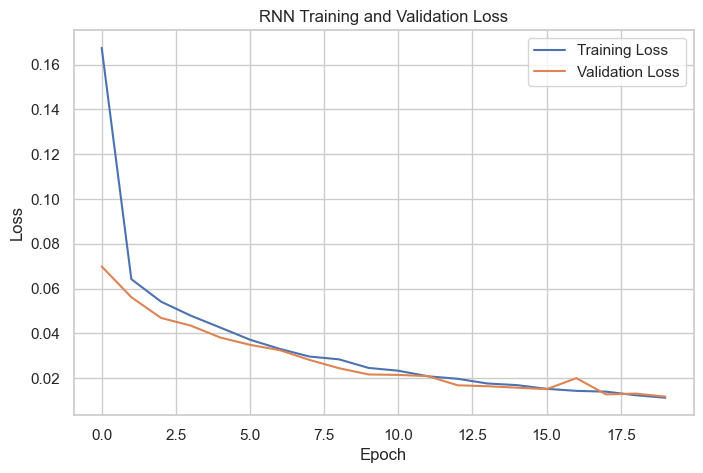

In [31]:
# ============================================================
# Plot Loss Curves
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNN Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

The RNN loss curves show stable convergence. Training loss decreased sharply during the first few epochs and then continued decreasing more gradually.

Validation loss followed a similar downward trend and remained close to the training loss, suggesting that the model generalised well to unseen validation sequences.

There is no major divergence between training and validation loss, so there is little evidence of severe overfitting.

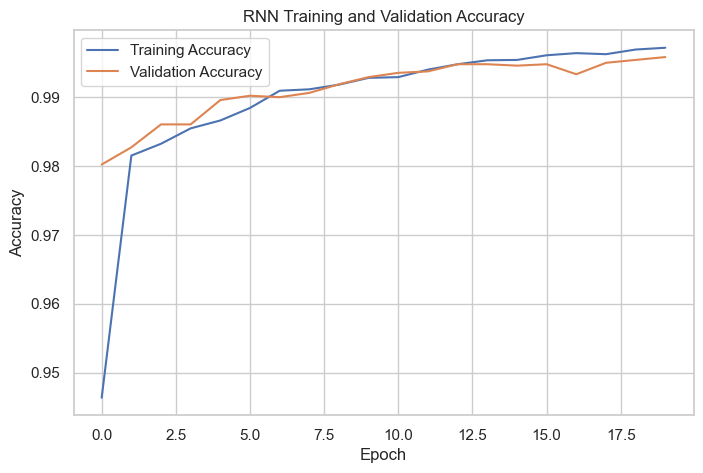

In [32]:
# ============================================================
# Plot Accuracy Curves
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(history["train_accuracy"], label="Training Accuracy")
plt.plot(history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("RNN Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

The RNN accuracy curves show that the model quickly learned useful discriminative patterns from the ECG sequences.

Training accuracy increased steadily and exceeded 99% by the end of training. Validation accuracy also remained consistently high and closely followed the training curve.

Although the accuracy is very strong, it should be interpreted carefully because the dataset is imbalanced and dominated by normal beats. Therefore, the classification report and macro F1-score are needed for a more balanced evaluation.

In biomedical classification problems, macro F1-score is especially important because clinically significant arrhythmias may occur rarely despite having high diagnostic importance.

### 3.5 Test Set Evaluation

The final RNN model was evaluated on the held-out test set using a classification report and confusion matrix.

The classification report includes precision, recall, and F1-score for each class. Macro F1 is especially important because it gives equal weight to N, S, and V, rather than being dominated by the majority normal class.

In [33]:
# ============================================================
# Generate Test Predictions
# ============================================================

model.eval()

test_predictions = []
test_true_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)

        logits = model(X_batch)
        predictions = torch.argmax(logits, dim=1)

        test_predictions.extend(predictions.cpu().numpy())
        test_true_labels.extend(y_batch.numpy())

test_predictions = np.array(test_predictions)
test_true_labels = np.array(test_true_labels)

In [34]:
# ============================================================
# Classification Report
# ============================================================

class_names = ["N", "S", "V"]

report = classification_report(
    test_true_labels,
    test_predictions,
    target_names=class_names,
    digits=4
)

print(report)

              precision    recall  f1-score   support

           N     0.9961    0.9989    0.9975      5658
           S     0.7381    0.7561    0.7470        41
           V     0.9931    0.9383    0.9649       308

    accuracy                         0.9942      6007
   macro avg     0.9091    0.8978    0.9032      6007
weighted avg     0.9942    0.9942    0.9941      6007



The RNN achieved an overall test accuracy of 99.42%, indicating strong overall classification performance.

The N class achieved very high precision, recall, and F1-score because normal beats dominate the dataset and are easier for the model to learn.

The V class also performed strongly, with an F1-score of 0.9649 and recall of 0.9383, suggesting that ventricular ectopic beats were well captured by the temporal and morphology-based features.

The weakest performance occurred in the S class, with recall of 0.7561 and F1-score of 0.7470. This shows that many supraventricular ectopic beats were misclassified, most likely because the class is severely underrepresented and can be morphologically similar to normal beats.

The macro F1-score of 0.9032 is more informative than accuracy because it gives equal importance to all classes, while the weighted F1-score is strongly influenced by the dominant N class.

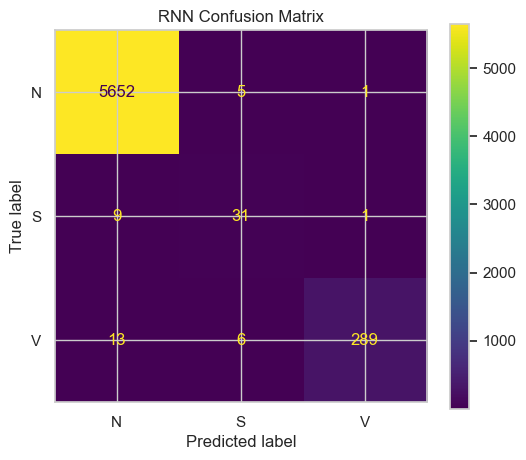

In [35]:
# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(
    test_true_labels,
    test_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format="d")
plt.title("RNN Confusion Matrix")
plt.show()

The RNN confusion matrix confirms that most errors occurred in the minority S class.

For the N class, 5,652 out of 5,658 beats were correctly classified, showing excellent recognition of normal rhythm patterns.

For the V class, 289 out of 308 beats were correctly classified, indicating strong detection of ventricular ectopic beats.

For the S class, only 31 out of 41 beats were correctly classified. Many S beats were predicted as N, which is consistent with the low S-class recall in the classification report. This highlights the effect of class imbalance and the difficulty of distinguishing supraventricular ectopic beats from normal beats.

### 3.6 Vanishing Gradient Discussion

Vanilla RNNs are affected by the vanishing gradient problem. During backpropagation through time, gradients must pass through repeated recurrent operations. As the sequence length increases, these gradients can become very small, making it difficult for the model to learn dependencies from earlier timesteps.

In this assignment, the input sequence length is only 10 beats. This short window partially reduces the severity of vanishing gradients because the model does not need to preserve information across a long sequence.

However, if the model were trained on much longer ECG sequences, a vanilla RNN would likely struggle to retain useful information from distant beats. This could reduce its ability to recognise rhythm patterns that develop over longer time periods.

This limitation motivates the LSTM extension. LSTMs use gating mechanisms to control what information is stored, updated, or forgotten, making them better suited for longer temporal dependencies.

### 3.7 Extension - LSTM Sequence Classification

As an extension, the vanilla RNN was replaced with an LSTM while keeping the same main hyperparameters:

- input size = 8
- hidden size = 64
- number of layers = 1
- learning rate = 0.001
- epochs = 20
- batch size = 64

This makes the comparison between RNN and LSTM fair because the main difference is the recurrent unit itself.

In [36]:
# ============================================================
# LSTM Model
# ============================================================

class LSTMClassifier(nn.Module):
    """
    LSTM classifier for ECG sequence classification.
    """

    def __init__(self, input_size, hidden_size, num_layers, num_classes):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        batch_size = x.size(0)

        h0 = torch.zeros(
            self.num_layers,
            batch_size,
            self.hidden_size,
            device=x.device
        )

        c0 = torch.zeros(
            self.num_layers,
            batch_size,
            self.hidden_size,
            device=x.device
        )

        output, (hidden, cell) = self.lstm(x, (h0, c0))

        final_timestep_output = output[:, -1, :]

        logits = self.classifier(final_timestep_output)

        return logits


lstm_model = LSTMClassifier(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES
).to(device)

lstm_criterion = nn.CrossEntropyLoss()

lstm_optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=LEARNING_RATE
)

print(lstm_model)

LSTMClassifier(
  (lstm): LSTM(8, 64, batch_first=True)
  (classifier): Linear(in_features=64, out_features=3, bias=True)
)


The LSTM model was successfully initialised using the same main hyperparameters as the vanilla RNN.

The model contains one LSTM layer with 64 hidden units and a final fully connected layer with 3 output neurons.

Keeping the hidden size, number of layers, learning rate, batch size, and number of epochs the same makes the comparison between the vanilla RNN and LSTM fair. The main difference is the recurrent unit itself.

In [37]:
# ============================================================
# Train LSTM
# ============================================================

lstm_history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}

for epoch in range(NUM_EPOCHS):
    train_loss, train_accuracy = train_one_epoch(
        model=lstm_model,
        dataloader=train_loader,
        criterion=lstm_criterion,
        optimizer=lstm_optimizer,
        device=device
    )

    val_loss, val_accuracy = evaluate(
        model=lstm_model,
        dataloader=val_loader,
        criterion=lstm_criterion,
        device=device
    )

    lstm_history["train_loss"].append(train_loss)
    lstm_history["val_loss"].append(val_loss)
    lstm_history["train_accuracy"].append(train_accuracy)
    lstm_history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch 01/20 | Train Loss: 0.2182 | Val Loss: 0.0692 | Train Acc: 0.9354 | Val Acc: 0.9800
Epoch 02/20 | Train Loss: 0.0601 | Val Loss: 0.0462 | Train Acc: 0.9814 | Val Acc: 0.9873
Epoch 03/20 | Train Loss: 0.0453 | Val Loss: 0.0384 | Train Acc: 0.9865 | Val Acc: 0.9881
Epoch 04/20 | Train Loss: 0.0370 | Val Loss: 0.0324 | Train Acc: 0.9895 | Val Acc: 0.9904
Epoch 05/20 | Train Loss: 0.0304 | Val Loss: 0.0262 | Train Acc: 0.9915 | Val Acc: 0.9919
Epoch 06/20 | Train Loss: 0.0256 | Val Loss: 0.0216 | Train Acc: 0.9931 | Val Acc: 0.9933
Epoch 07/20 | Train Loss: 0.0225 | Val Loss: 0.0184 | Train Acc: 0.9941 | Val Acc: 0.9942
Epoch 08/20 | Train Loss: 0.0193 | Val Loss: 0.0173 | Train Acc: 0.9948 | Val Acc: 0.9946
Epoch 09/20 | Train Loss: 0.0168 | Val Loss: 0.0158 | Train Acc: 0.9955 | Val Acc: 0.9956
Epoch 10/20 | Train Loss: 0.0148 | Val Loss: 0.0151 | Train Acc: 0.9964 | Val Acc: 0.9954
Epoch 11/20 | Train Loss: 0.0131 | Val Loss: 0.0144 | Train Acc: 0.9971 | Val Acc: 0.9952
Epoch 12/2

The LSTM was trained for 20 epochs using the same training procedure and hyperparameters as the vanilla RNN.

Training loss decreased from 0.2182 to 0.0055, while validation loss decreased from 0.0692 to 0.01265. Training accuracy increased from 93.54% to 99.91%, and validation accuracy reached 99.69% by the final epoch.

The LSTM showed stable convergence and slightly stronger final validation performance than the vanilla RNN.

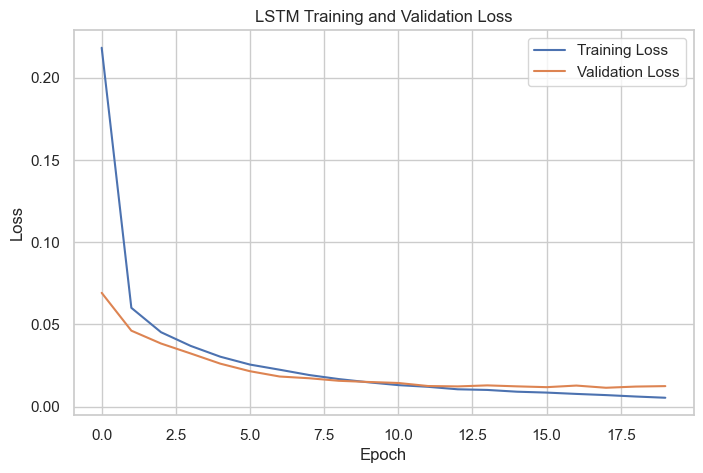

In [38]:
# ============================================================
# Plot LSTM Loss Curves
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(lstm_history["train_loss"], label="Training Loss")
plt.plot(lstm_history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

The LSTM loss curves show consistent convergence over the 20 epochs.

Training loss decreased steadily, while validation loss followed a similar downward trend. The validation loss remained close to the training loss, indicating good generalisation.

Compared with the vanilla RNN, the LSTM achieved a slightly lower final validation loss. However, whether this translates into better generalisation on the test set is assessed in the evaluation section.

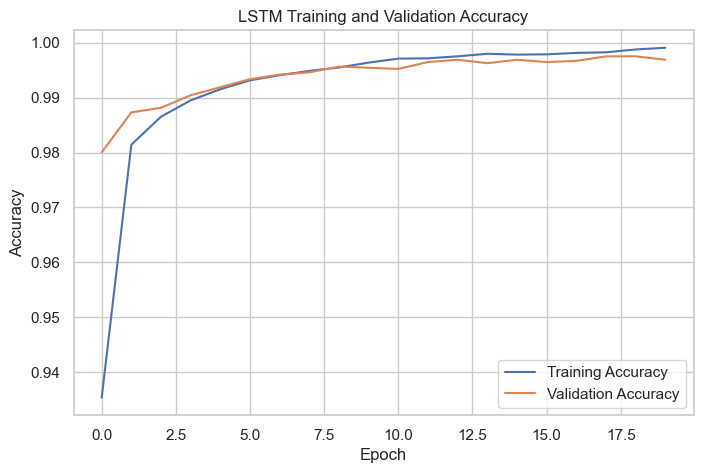

In [39]:
# ============================================================
# Plot LSTM Accuracy Curves
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(lstm_history["train_accuracy"], label="Training Accuracy")
plt.plot(lstm_history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

The LSTM accuracy curves show strong and stable learning behaviour.

Training accuracy increased steadily throughout the 20 epochs, while validation accuracy remained close to the training accuracy. This suggests that the model did not suffer from severe overfitting.

The final validation accuracy was slightly higher than the vanilla RNN.

In [40]:
# ============================================================
# LSTM Test Predictions
# ============================================================

lstm_model.eval()

lstm_test_predictions = []
lstm_test_true_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)

        logits = lstm_model(X_batch)
        predictions = torch.argmax(logits, dim=1)

        lstm_test_predictions.extend(predictions.cpu().numpy())
        lstm_test_true_labels.extend(y_batch.numpy())

lstm_test_predictions = np.array(lstm_test_predictions)
lstm_test_true_labels = np.array(lstm_test_true_labels)

Predictions were generated on the held-out test set using the trained LSTM model.

The same test set used for the vanilla RNN was used here, which allows a fair direct comparison between the two recurrent architectures.

In [41]:
# ============================================================
# LSTM Classification Report
# ============================================================

lstm_report = classification_report(
    lstm_test_true_labels,
    lstm_test_predictions,
    target_names=class_names,
    digits=4
)

print(lstm_report)

              precision    recall  f1-score   support

           N     0.9963    0.9993    0.9978      5658
           S     0.7297    0.6585    0.6923        41
           V     0.9831    0.9416    0.9619       308

    accuracy                         0.9940      6007
   macro avg     0.9030    0.8665    0.8840      6007
weighted avg     0.9938    0.9940    0.9939      6007



The LSTM achieved an overall test accuracy of 99.40%, which is slightly lower than the vanilla RNN (99.42%).

The macro F1-score decreased from 0.9032 for the RNN to 0.8840 for the LSTM. This indicates that at this sequence length, the vanilla RNN produced slightly more balanced performance across the three classes.

The S-class recall decreased from 0.7561 to 0.6585, showing that the LSTM was not better at detecting supraventricular ectopic beats in this setting. The advantage of the LSTM's gating mechanism was not evident at a window length of only 10 beats.

The V class remained strong, with an F1-score of 0.9619 and recall of 0.9416. V recall was slightly higher than in the RNN (0.9383), although the overall minority-class balance did not improve.

The weighted F1-score remained high because the dataset is dominated by normal beats, so macro F1 is the more useful metric for comparing the two models.

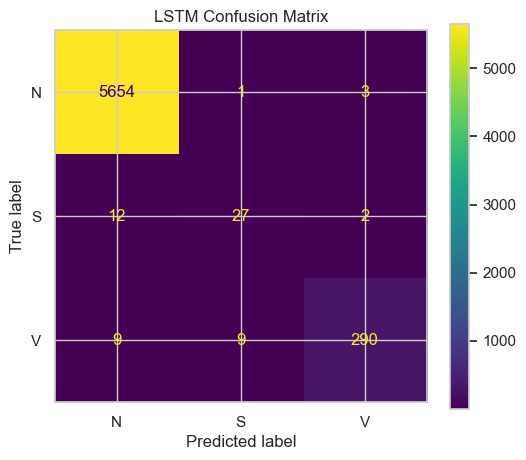

In [42]:
# ============================================================
# LSTM Confusion Matrix
# ============================================================

lstm_cm = confusion_matrix(
    lstm_test_true_labels,
    lstm_test_predictions
)

lstm_disp = ConfusionMatrixDisplay(
    confusion_matrix=lstm_cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(6, 5))
lstm_disp.plot(ax=ax, values_format="d")
plt.title("LSTM Confusion Matrix")
plt.show()

The LSTM confusion matrix shows slightly reduced recognition of the S class compared with the vanilla RNN.

For the N class, 5,654 out of 5,658 beats were correctly classified, showing that the model preserved excellent normal-beat detection.

For the S class, 27 out of 41 beats were correctly classified, compared with 31 out of 41 for the RNN. This confirms the slight decrease in S-class recall observed in the classification report.

For the V class, 290 out of 308 beats were correctly classified. This is marginally stronger than the vanilla RNN, representing the only minority-class gain of the LSTM in this setting.

Overall, the LSTM did not produce a more balanced error distribution at this sequence length. The vanilla RNN showed slightly better detection of supraventricular ectopic beats, while the two models performed comparably on ventricular ectopic beats.

## Task 4: Model Comparison & Evaluation (Irene López)

### 4.1 RNN and LSTM Performance Comparison

In [43]:
# ============================================================
# Extract Summary Metrics for Task 4
# ============================================================

from sklearn.metrics import accuracy_score, f1_score

rnn_accuracy = accuracy_score(test_true_labels, test_predictions)
rnn_macro_f1 = f1_score(test_true_labels, test_predictions, average="macro")
rnn_weighted_f1 = f1_score(test_true_labels, test_predictions, average="weighted")

lstm_accuracy = accuracy_score(lstm_test_true_labels, lstm_test_predictions)
lstm_macro_f1 = f1_score(lstm_test_true_labels, lstm_test_predictions, average="macro")
lstm_weighted_f1 = f1_score(lstm_test_true_labels, lstm_test_predictions, average="weighted")

comparison_table = {
    "Model": ["RNN", "LSTM"],
    "Accuracy": [rnn_accuracy, lstm_accuracy],
    "Macro F1": [rnn_macro_f1, lstm_macro_f1],
    "Weighted F1": [rnn_weighted_f1, lstm_weighted_f1]
}

comparison_df = pd.DataFrame(comparison_table)

comparison_df

,Model,Accuracy,Macro F1,Weighted F1
0,RNN,0.994173,0.903153,0.994148
1,LSTM,0.994007,0.883986,0.993866


The comparison table shows that both recurrent models achieved very high overall accuracy. However, accuracy alone is not sufficient for this dataset because the class distribution is imbalanced.

The vanilla RNN achieved a macro F1-score of 0.9032, while the LSTM produced a slightly lower value of 0.884. This indicates that the RNN produced marginally more balanced performance across the heartbeat classes.

The largest difference occurred in the supraventricular ectopic class (S), where recall decreased from 0.7561 with the RNN to 0.6585 with the LSTM, suggesting that the gating mechanism of the LSTM did not provide an advantage at this sequence length.

The weighted F1-scores remained similar for both models because the weighted average is strongly influenced by the dominant normal class.
Overall, the vanilla RNN showed slightly better minority-class sensitivity while maintaining similarly high overall accuracy.

### 4.2 Deployment Recommendation


**1 - Classification performance.** The vanilla RNN reaches a macro F1 of 0.9032 vs. 0.884 for the LSTM. The RNN also performs better on the S class, where recall is 0.7561 compared to 0.6585 for the LSTM. We use macro F1 as the main metric because accuracy is misleading when 94% of beats are class N [3]. In a cardiac monitor, an undetected V beat is a much bigger problem than a false alarm, so minority-class recall is what matters clinically.

**2 - Latency.** Both models work on a 10-beat window, roughly 10 seconds at resting heart rate. The LSTM has an extra cell state but at hidden size 64 the difference in inference time is negligible. Neither model is a bottleneck for real-time use.

**3 - Interpretability.** Both models use the same eight features (RR intervals, QRS morphology, ST segment) from MIT-BIH [2, 4], so the inputs at least have a clear clinical meaning even if the weights do not. The RNN is slightly more transparent due to its simpler recurrent structure, which further supports its selection.

**4 - Cost of false negatives on V beats.** Undetected ventricular ectopics can deteriorate into ventricular tachycardia or fibrillation [5]. The RNN holds V-class performance steady (F1 0.9649, recall 0.9383) while also achieving better S-class recall. At a window length of only 10 beats, the LSTM gating mechanism does not provide the additional long-range memory benefit it would offer over longer sequences [1].

**Caveat.** The reported test-set performance should be interpreted with two limitations in
mind. First, consecutive sliding windows overlap by nine out of ten beats, so adjacent windows may appear on opposite sides of the train/test split. This can cause performance estimates to be slightly optimistic. Second, both models were trained and tested on a random split of the same 14 records [2]. Testing on patients not seen during training would be a harder and more realistic evaluation, and macro F1 would likely drop for both. A patient-level split combined with class-weighted loss could provide a more conservative and clinically honest benchmark, and could further improve detection of the minority S class.

---

**References**

[1] Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation*, 9(8), 1735–1780.

[2] Moody, G. B., & Mark, R. G. (2001). The impact of the MIT-BIH arrhythmia database. *IEEE Engineering in Medicine and Biology Magazine*, 20(3), 45–50.

[3] Sokolova, M., & Lapalme, G. (2009). A systematic analysis of performance measures for classification tasks. *Information Processing & Management*, 45(4), 427–437.

[4] Goldberger, A. L., et al. (2000). PhysioBank, PhysioToolkit, and PhysioNet. *Circulation*, 101(23), e215–e220.

[5] Clifford, G. D., et al. (2006). *Advanced Methods and Tools for ECG Data Analysis*. Artech House.